In [31]:
import matplotlib.pyplot as plt
import json
import os
import pandas as pd

In [32]:
MODELS=[
  "hubble-1b-500b_toks-perturbed-hf",
  "hubble-1b-500b_toks-standard-hf",
  "hubble-8b-500b_toks-standard-hf",
  "hubble-8b-500b_toks-perturbed-hf",
]

In [33]:
TASKS=(
  "mia_gutenberg_popular_eval",
  "mia_gutenberg_unpopular_eval",
  "mia_passage_wikipedia_eval",
  "mia_yago_biographies_eval",
  "mia_mmlu_eval",
)

In [34]:
base_path = '/NS/llm-pretraining/work/afkhan/HubbleSuite/open-unlearning/saves/eval'

In [35]:
dups = [1, 4, 16, 64, 256]

In [36]:
files = os.listdir(base_path)

In [37]:
file_name = "TOFU_SUMMARY.json"

In [38]:
all_data = {}

In [39]:
for task in TASKS:
    for model in MODELS:
        relevant_files = [f for f in files if (model in f and task in f)]
        
        base_file_name = task + '_' + model
        try:
            relevant_files.remove(base_file_name)
        except Exception as e:
            print(f"Base file {base_file_name} not found")
            print(f"relevant_files: {relevant_files}")

        # relevant files on _ and sort by int of last part
        relevant_files = sorted(relevant_files, key=lambda x: int(x.split('_')[-1].split('.')[0]))

        data = {}
        
        base_path_data_path = os.path.join(base_path, base_file_name, file_name)
        with open(base_path_data_path, 'r') as f:
            base_data = json.load(f)

        data['Base'] = base_data

        for f in relevant_files:
            dup = f.split('_')[-1].split('.')[0]
            path = os.path.join(base_path, f, file_name)
            with open(path, 'r') as f:
                data[dup] = json.load(f)

        all_data[base_file_name] = data

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Data Preprocessing (including 'Base' as parameter 0) ---
records = []
for key, val in all_data.items():
    # Split the key to extract evaluation and model names
    eval_name, model_name = key.replace('mia_', '').split('_eval_')
    for sub_key, sub_val in val.items():
        # Map 'Base' to parameter 0, otherwise convert the key to an integer
        parameter_value = 0 if sub_key == 'Base' else int(sub_key)
        
        if parameter_value == 0:
            forget_set_dup = 'Dup = 0 v/s Dup > 0'
        elif parameter_value > 0:
            forget_set_dup = f'Dup = 0 v/s Dup = {parameter_value}'
        else:
            raise ValueError("Unexpected sub_key value")

        record = {
            'evaluation': eval_name,
            'model': model_name,
            'parameter_value': parameter_value,   # ✅ keep for sorting
            'forget_set_dup': forget_set_dup
        }
        record.update(sub_val)
        records.append(record)

# Create DataFrame
df = pd.DataFrame(records)

# --- 2. Sort rows ---
df = df.sort_values(by=["evaluation", "model", "parameter_value"]).reset_index(drop=True)

In [41]:
df.to_csv("mia_results.csv", index=False)

In [42]:
df

,evaluation,model,parameter_value,forget_set_dup,mia_loss,mia_min_k,mia_min_k_plus_plus,mia_zlib
0,gutenberg_popular,hubble-1b-500b_toks-perturbed-hf,0,Dup = 0 v/s Dup > 0,0.573555,0.573728,0.630915,0.566956
1,gutenberg_popular,hubble-1b-500b_toks-perturbed-hf,1,Dup = 0 v/s Dup = 1,0.496150,0.496844,0.554719,0.488119
2,gutenberg_popular,hubble-1b-500b_toks-perturbed-hf,16,Dup = 0 v/s Dup = 16,0.559538,0.558763,0.636025,0.553063
3,gutenberg_popular,hubble-1b-500b_toks-perturbed-hf,256,Dup = 0 v/s Dup = 256,0.995625,0.995563,0.999125,0.995875
4,gutenberg_popular,hubble-1b-500b_toks-standard-hf,0,Dup = 0 v/s Dup > 0,0.498426,0.498835,0.532551,0.487070
...,...,...,...,...,...,...,...,...
107,yago_biographies,hubble-8b-500b_toks-standard-hf,1,Dup = 0 v/s Dup = 1,0.489303,0.489425,0.499609,0.479447
108,yago_biographies,hubble-8b-500b_toks-standard-hf,4,Dup = 0 v/s Dup = 4,0.498633,0.498561,0.503079,0.500443
109,yago_biographies,hubble-8b-500b_toks-standard-hf,16,Dup = 0 v/s Dup = 16,0.519447,0.519479,0.507104,0.523072
110,yago_biographies,hubble-8b-500b_toks-standard-hf,64,Dup = 0 v/s Dup = 64,0.486355,0.486708,0.504952,0.481108


In [43]:
plot_folder = '/NS/llm-pretraining/work/afkhan/HubbleSuite/open-unlearning/plots'
os.makedirs(plot_folder, exist_ok=True)

# Plot by Eval

In [44]:
unique_evaluations = list(df['evaluation'].unique())

In [45]:
unique_models = list(df['model'].unique())

In [46]:
for uq in unique_evaluations:
    df_eval = df[df['evaluation'] == uq]
    
    plt.figure(figsize=(10, 6))

    for model in unique_models:
        df_model = df_eval[df_eval['model'] == model]
        break
    break

    

<Figure size 1000x600 with 0 Axes>

In [47]:
metrics_to_legend_mapping = {
    "mia_loss": "Loss",
    "mia_min_k": "Min-K%",
    "mia_min_k_plus_plus": "Min-K%++",
    "mia_zlib": "Zlib"
}

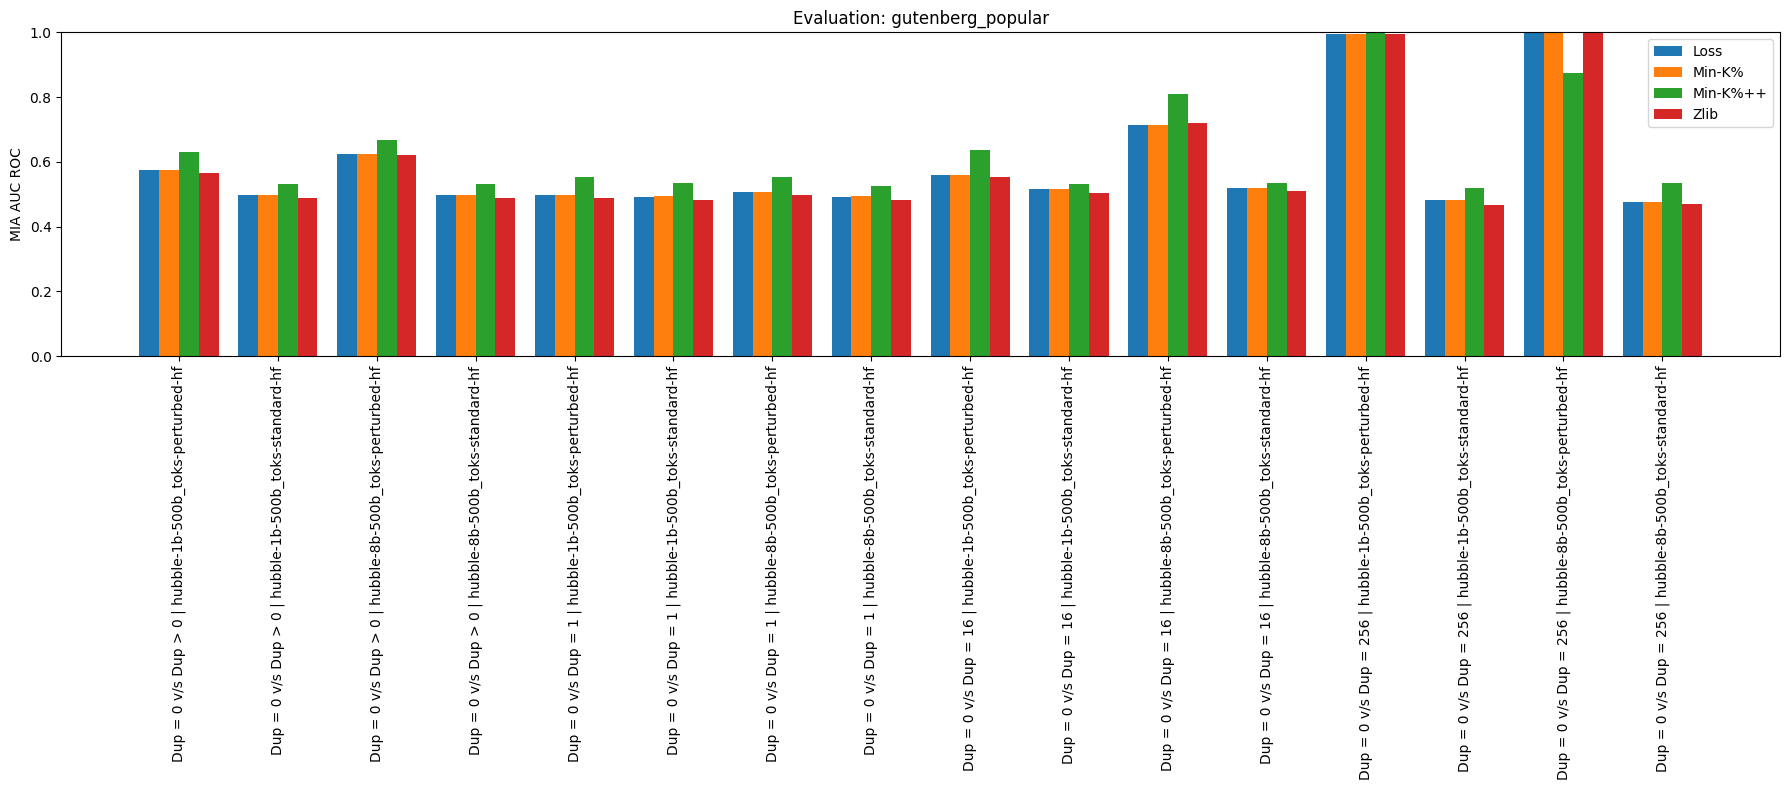

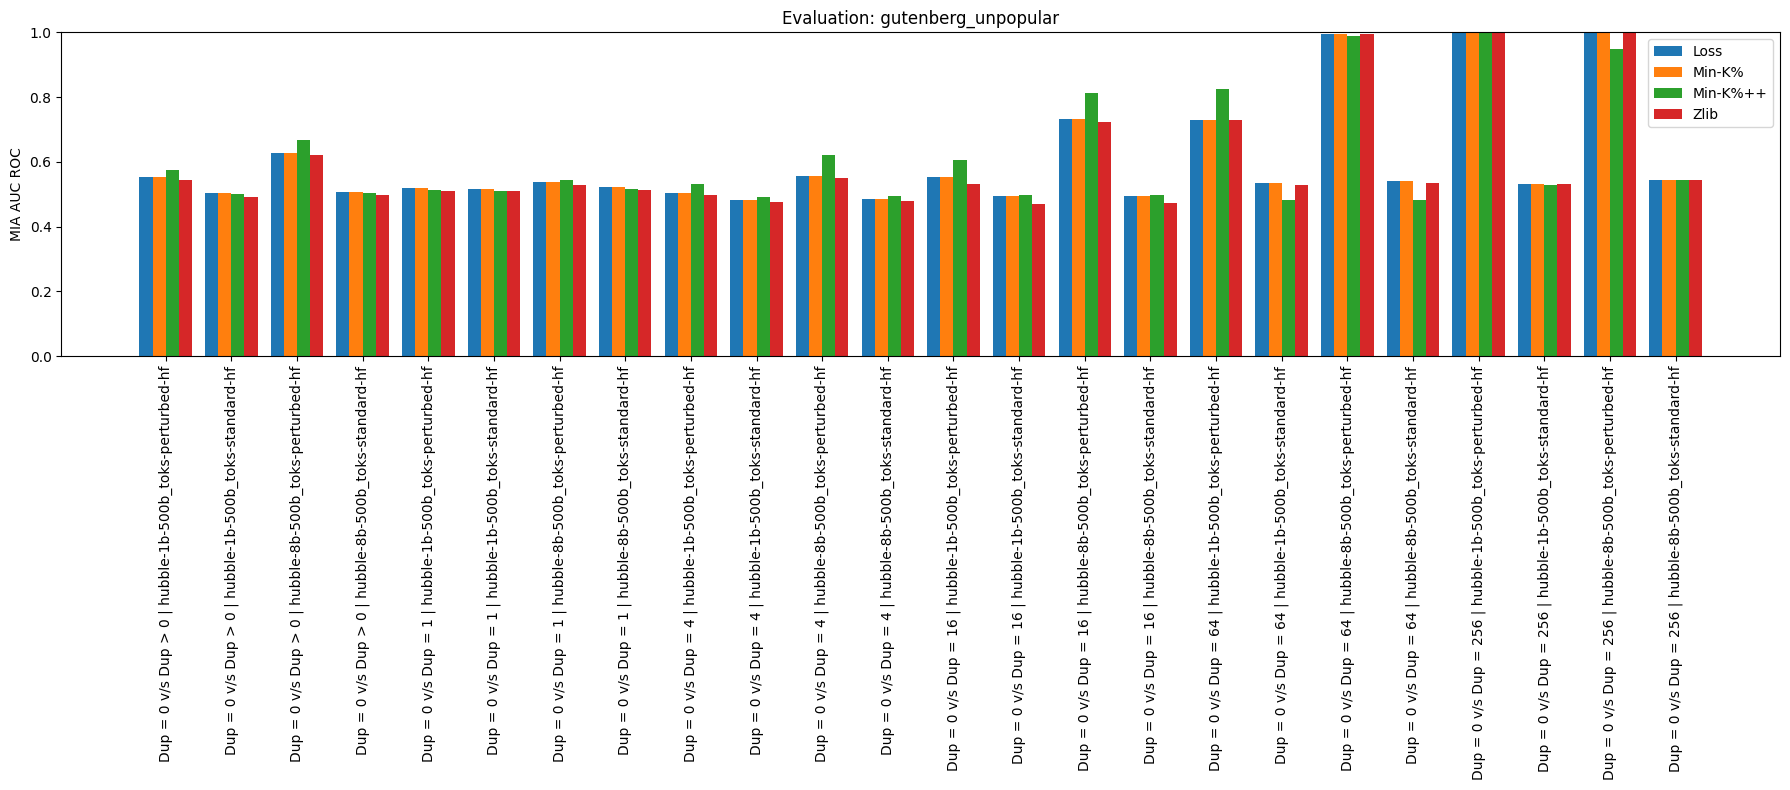

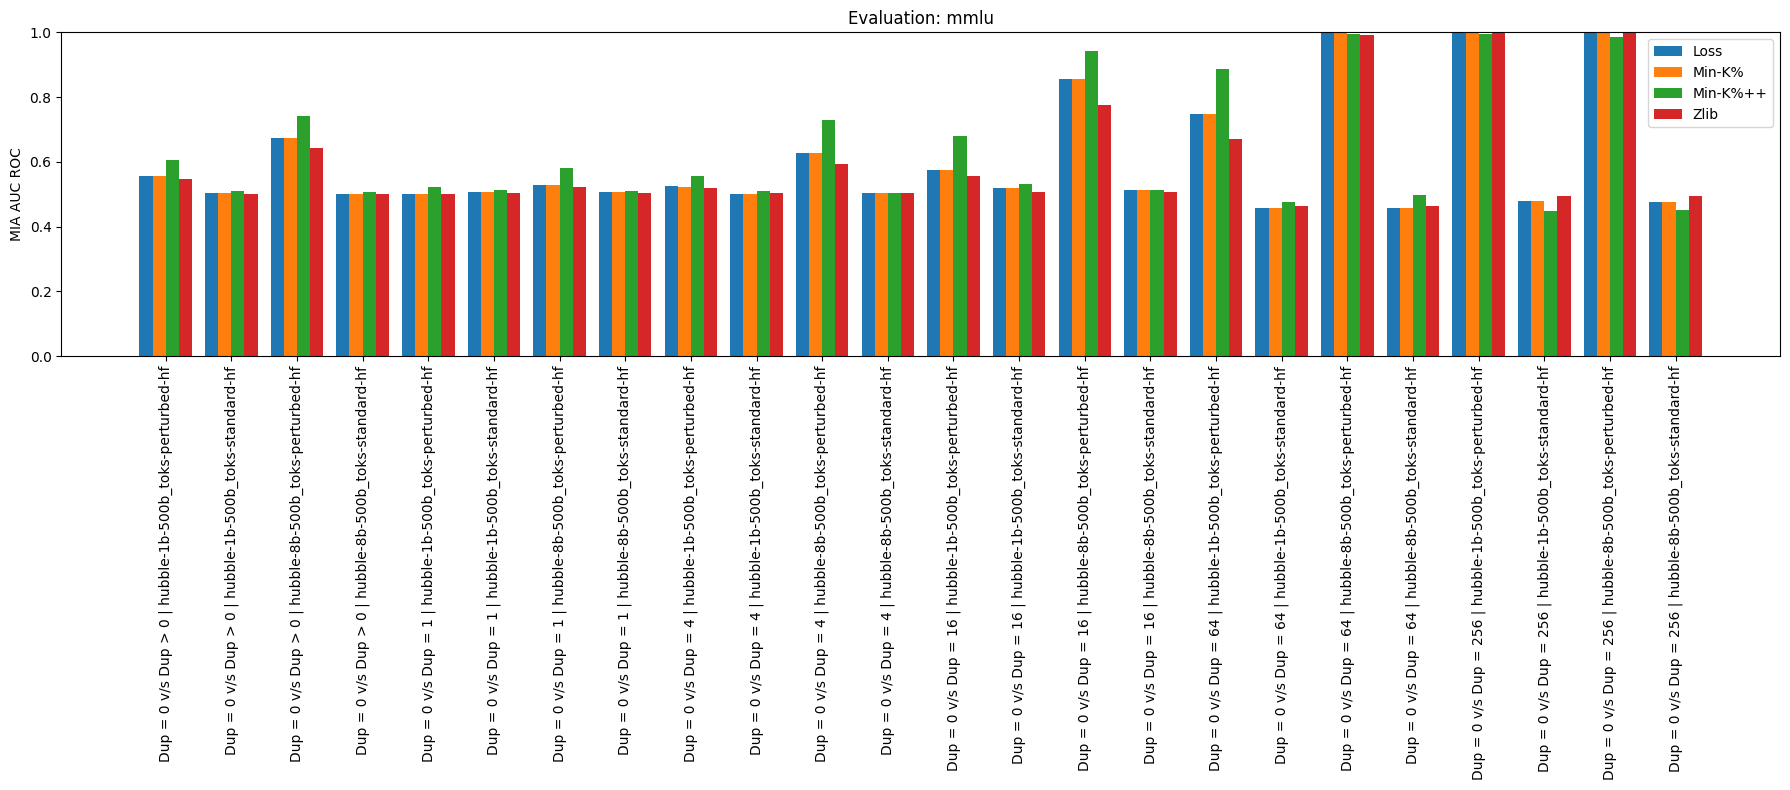

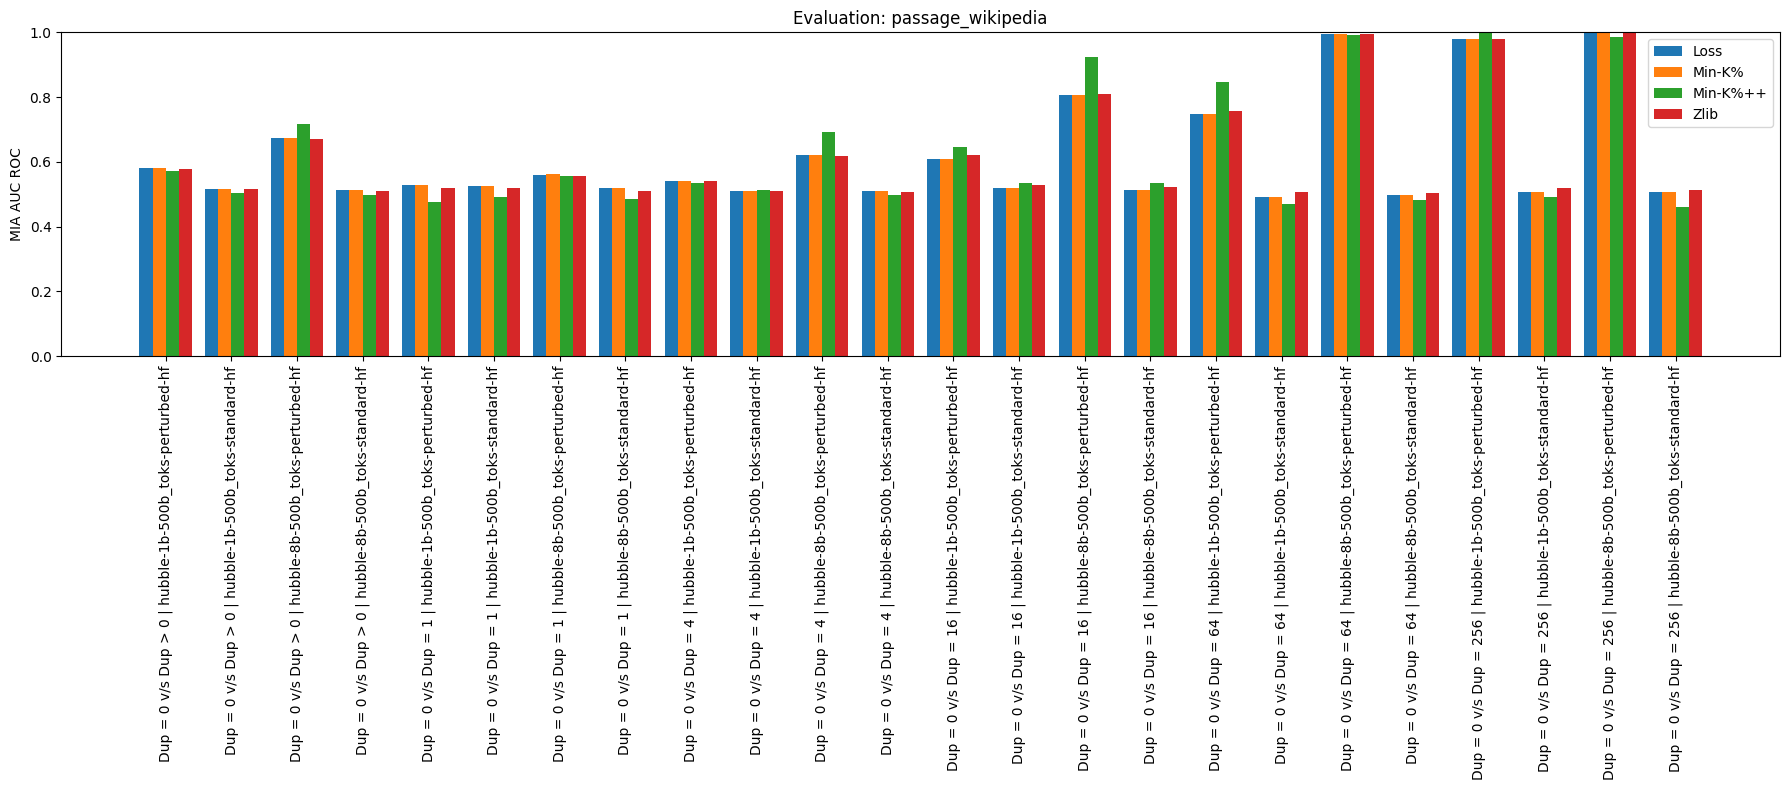

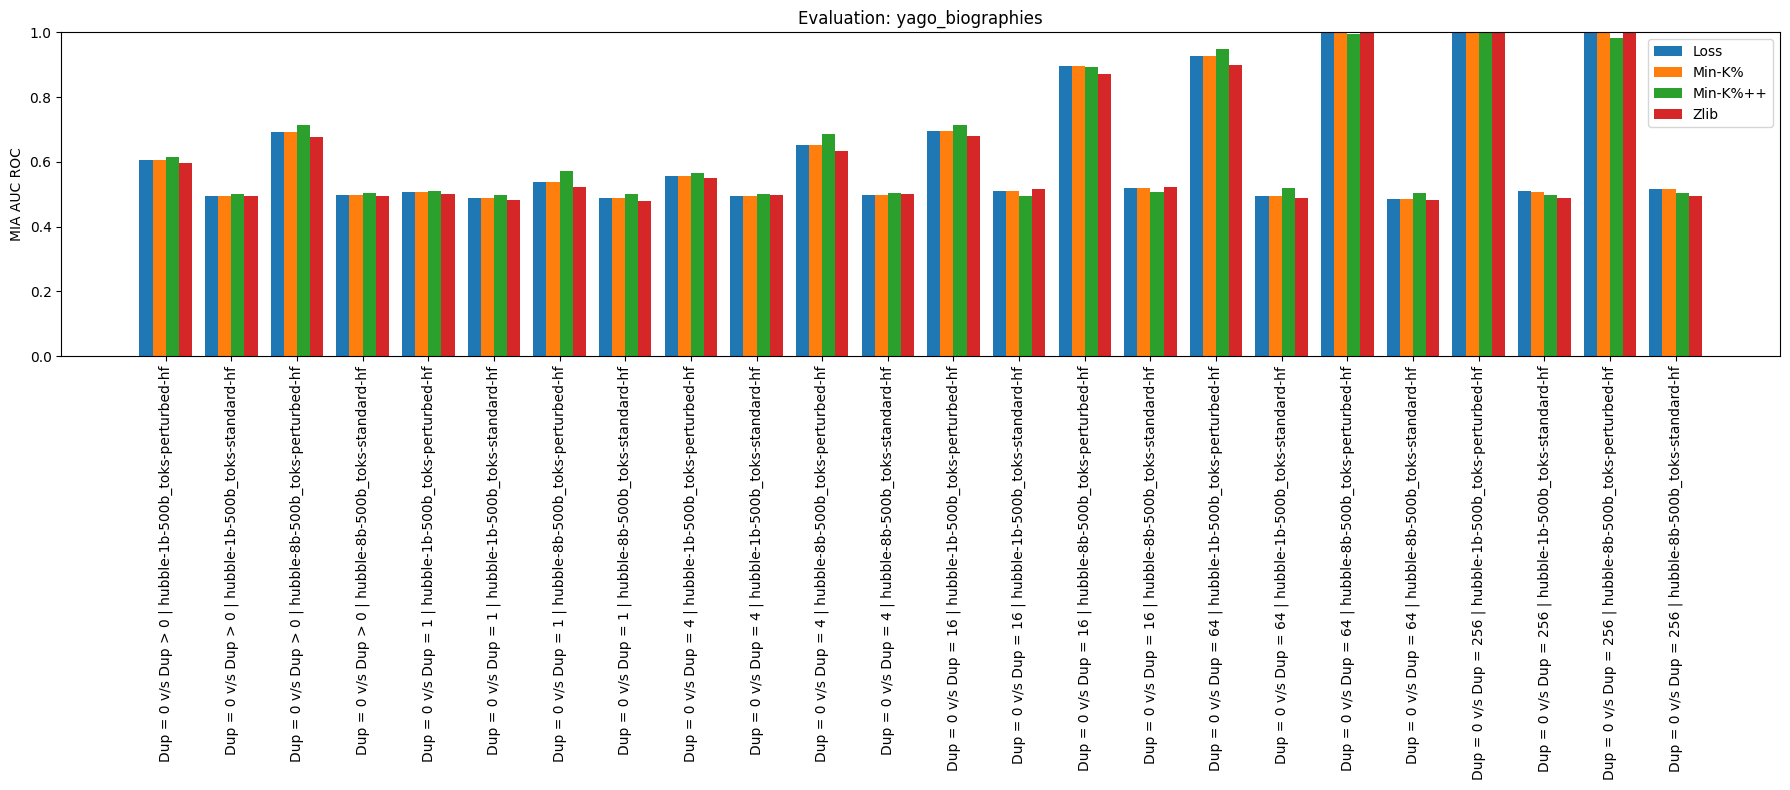

In [48]:
# Keep parameter_value in df_long for ordering
df_long = df.melt(
    id_vars=["evaluation", "model", "forget_set_dup", "parameter_value"],
    value_vars=["mia_loss", "mia_min_k", "mia_min_k_plus_plus", "mia_zlib"],
    var_name="metric",
    value_name="value"
)

for eval_name, df_eval in df_long.groupby("evaluation"):
    plt.figure(figsize=(18, 8))
    ax = plt.gca()

    # Sort numerically by parameter_value
    df_eval = df_eval.sort_values(by=["parameter_value", "model"])

    # Pivot
    df_pivot = df_eval.pivot_table(
        index=["parameter_value", "forget_set_dup", "model"],
        columns="metric",
        values="value"
    ).reset_index()

    bar_width = 0.2
    metrics = ["mia_loss", "mia_min_k", "mia_min_k_plus_plus", "mia_zlib"]
    x = range(len(df_pivot))

    for i, metric in enumerate(metrics):
        ax.bar(
            [pos + i * bar_width for pos in x],
            df_pivot[metric],
            width=bar_width,
            label=metrics_to_legend_mapping[metric]
        )

    ax.set_xticks([pos + 1.5*bar_width for pos in x])
    ax.set_xticklabels(
        df_pivot[["forget_set_dup", "model"]].astype(str).agg(" | ".join, axis=1),
        rotation=90
    )

    ax.set_ylim(0, 1.0)
    ax.set_title(f"Evaluation: {eval_name}")
    ax.set_ylabel("MIA AUC ROC")
    ax.legend()

    plt.tight_layout()

    save_path = os.path.join(plot_folder, f"eval_wise/evaluation_{eval_name}.png")
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path)


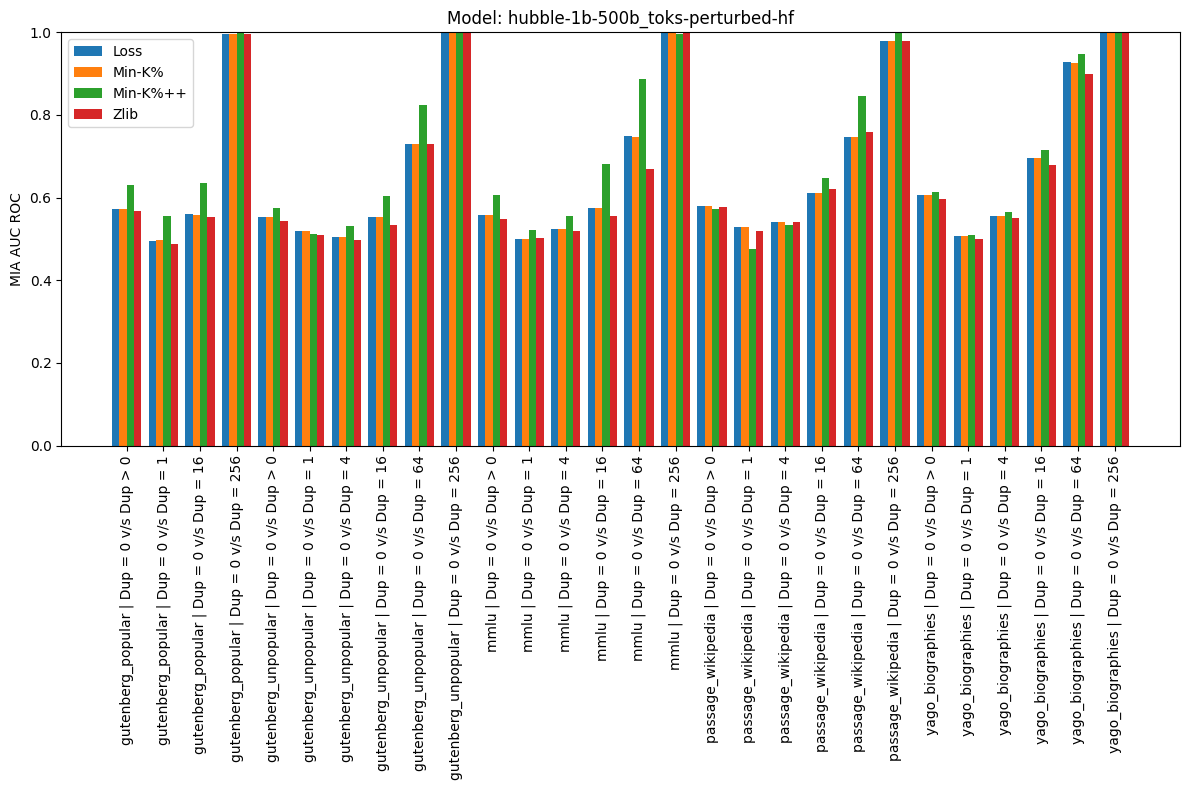

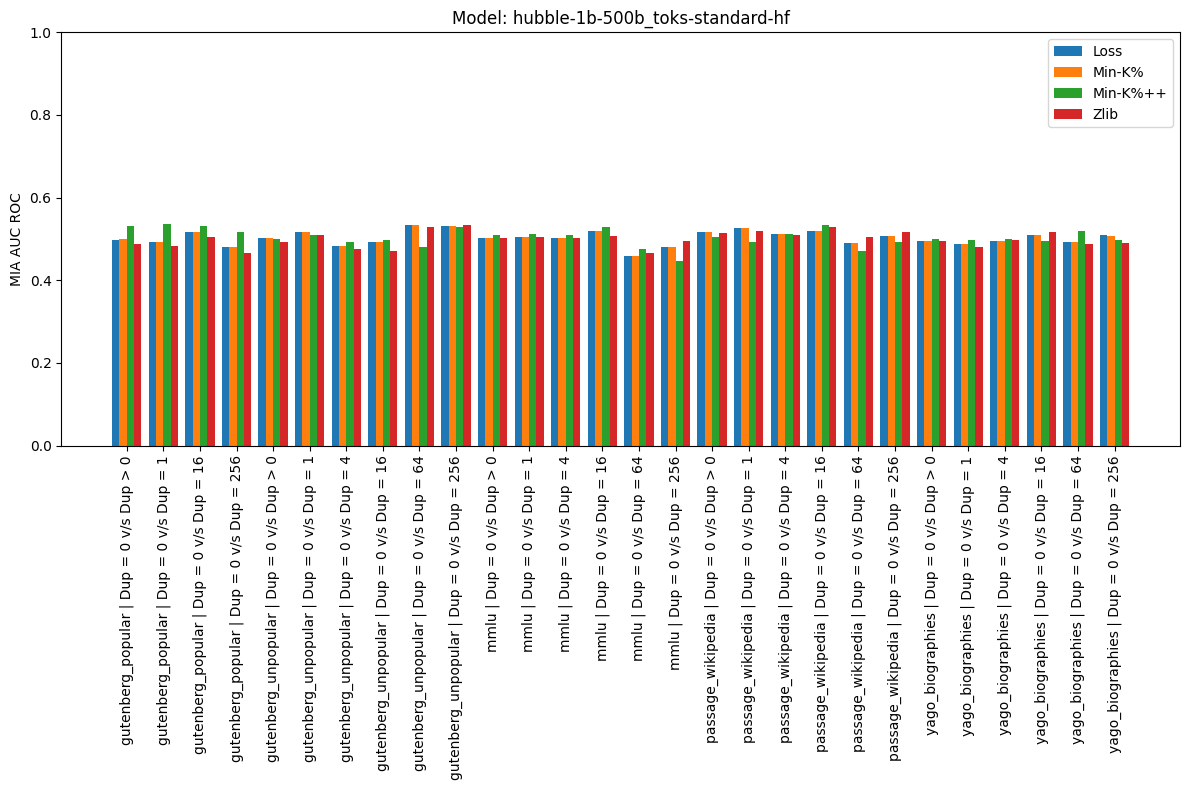

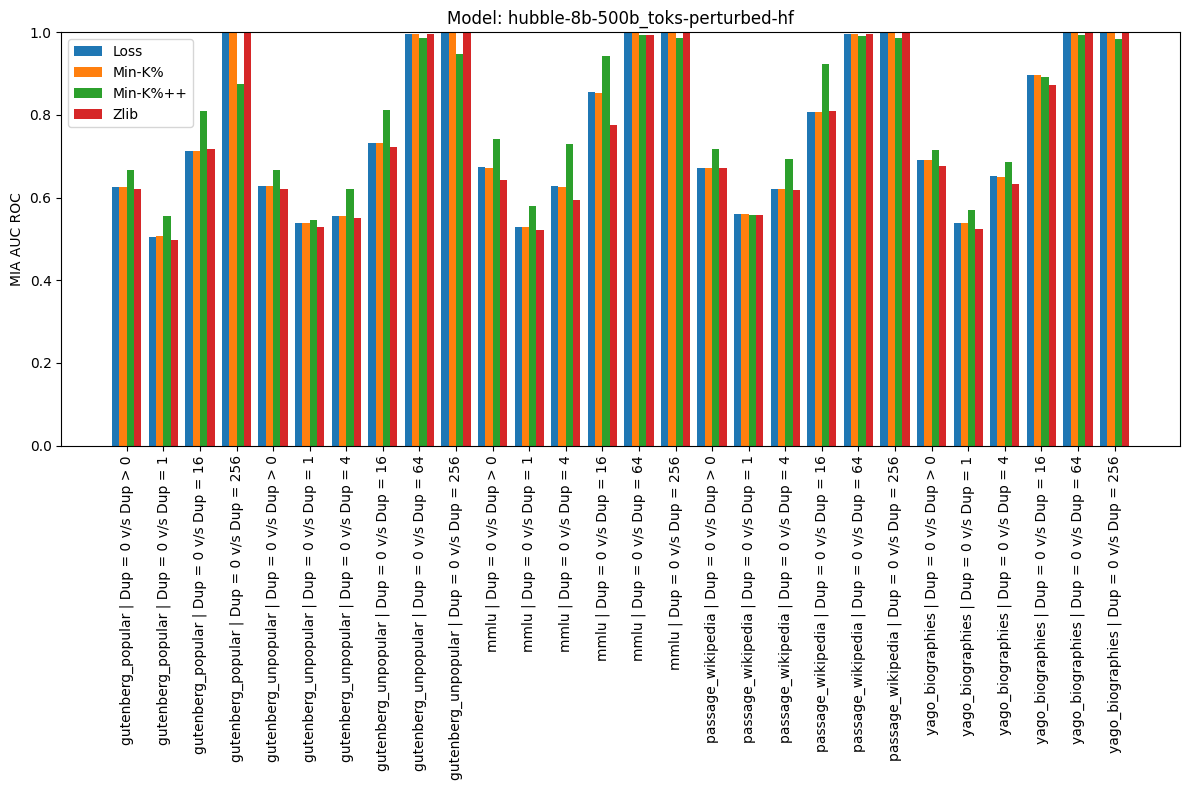

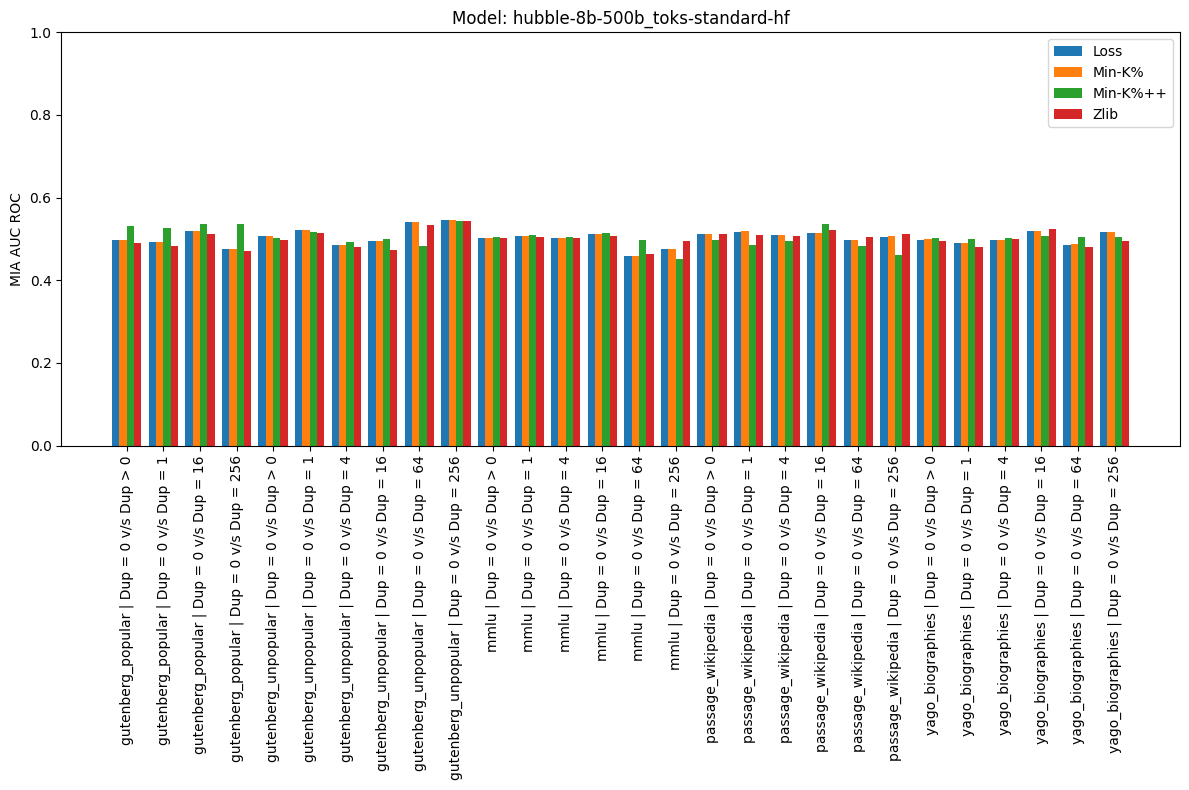

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Melt the MIA metrics into long format, keep parameter_value for numeric ordering
df_long = df.melt(
    id_vars=["evaluation", "model", "forget_set_dup", "parameter_value"],
    value_vars=["mia_loss", "mia_min_k", "mia_min_k_plus_plus", "mia_zlib"],
    var_name="metric",
    value_name="value"
)

# Plot per model
for model_name, df_model in df_long.groupby("model"):
    plt.figure(figsize=(12, 8))
    ax = plt.gca()

    # Sort numerically within each evaluation
    df_model = df_model.sort_values(by=["evaluation", "parameter_value"])

    # Pivot so that each metric is a column
    df_pivot = df_model.pivot_table(
        index=["evaluation", "parameter_value", "forget_set_dup"],
        columns="metric",
        values="value"
    ).reset_index()

    # X positions
    bar_width = 0.2
    metrics = ["mia_loss", "mia_min_k", "mia_min_k_plus_plus", "mia_zlib"]
    x = range(len(df_pivot))

    for i, metric in enumerate(metrics):
        ax.bar(
            [pos + i * bar_width for pos in x],
            df_pivot[metric],
            width=bar_width,
            label=metrics_to_legend_mapping[metric]
        )

    # X labels: show evaluation + dup
    ax.set_xticks([pos + 1.5 * bar_width for pos in x])
    ax.set_xticklabels(
        df_pivot[["evaluation", "forget_set_dup"]].astype(str).agg(" | ".join, axis=1),
        rotation=90
    )

    ax.set_ylim(0, 1.0)
    ax.set_title(f"Model: {model_name}")
    ax.set_ylabel("MIA AUC ROC")
    ax.legend()
    plt.tight_layout()

    save_path = os.path.join(plot_folder, f"model_wise/model_{model_name}.png")
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path)


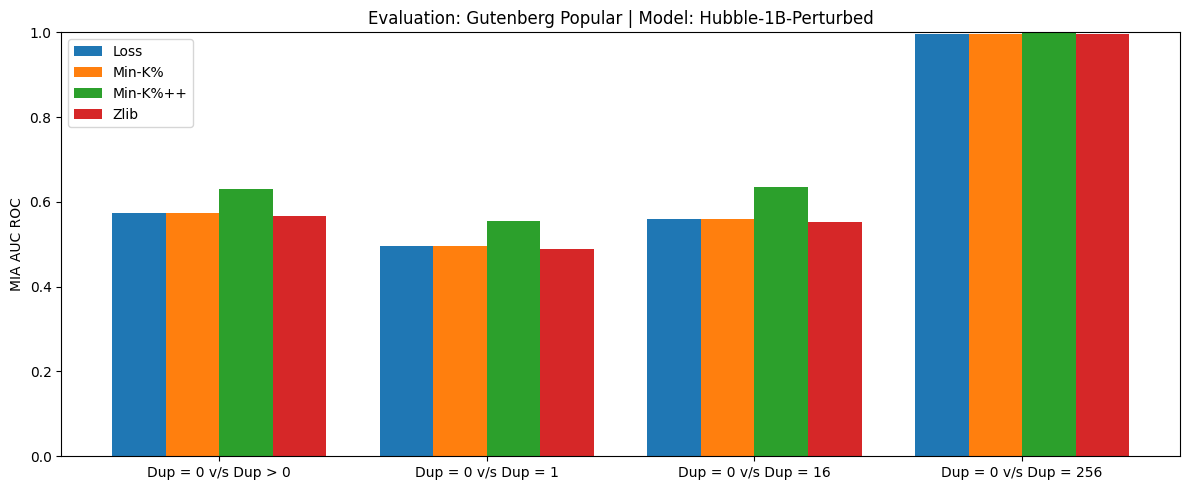

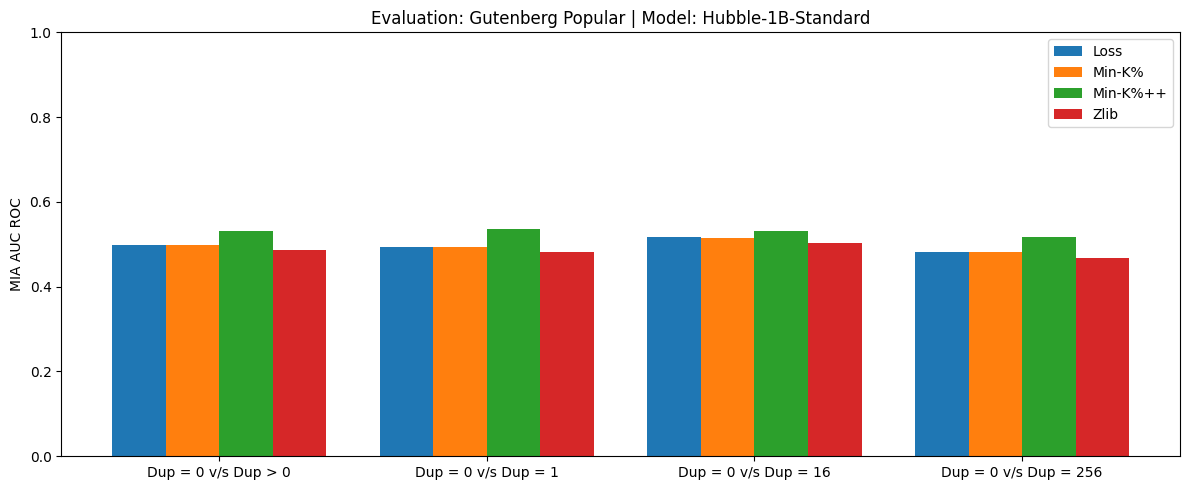

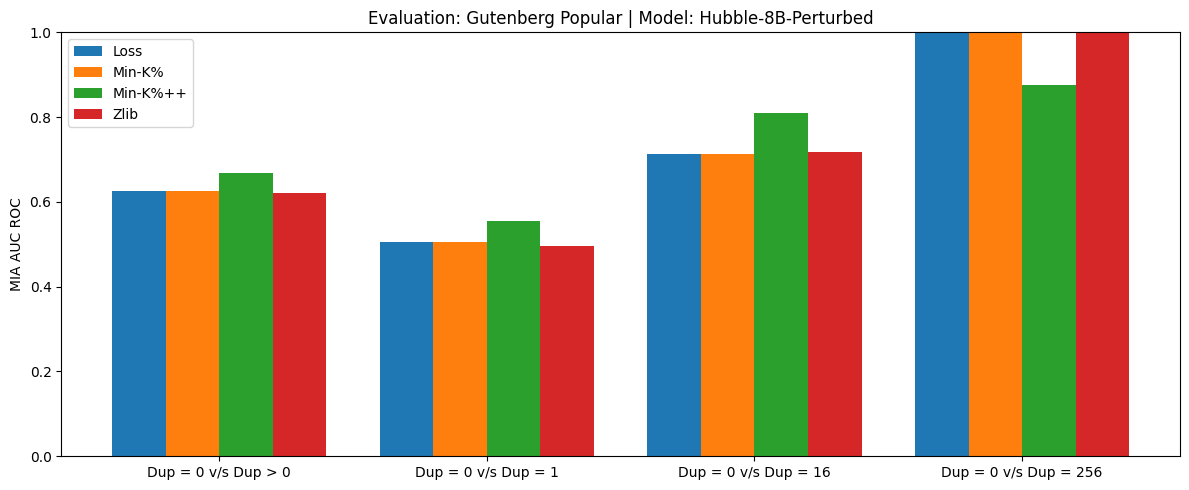

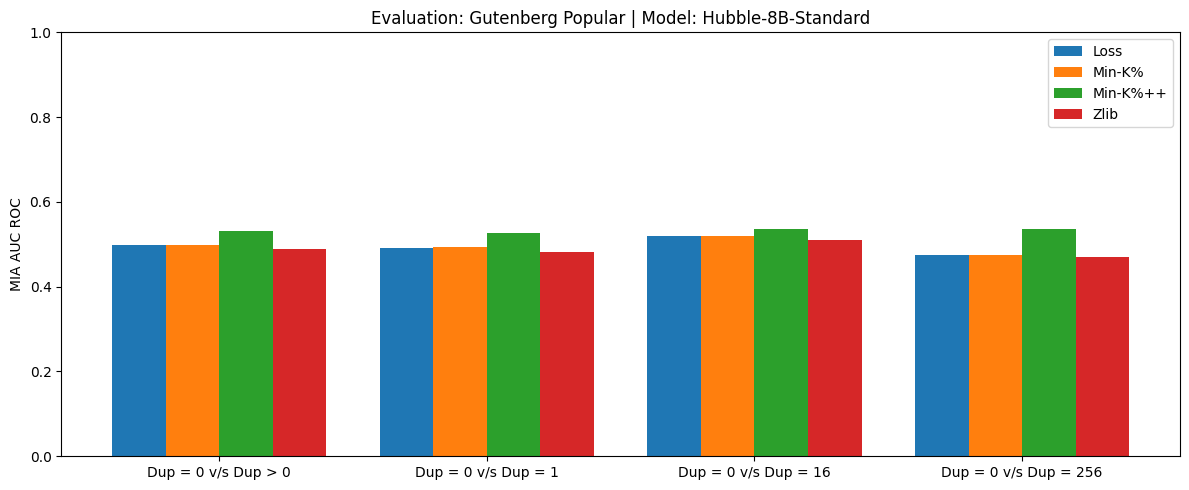

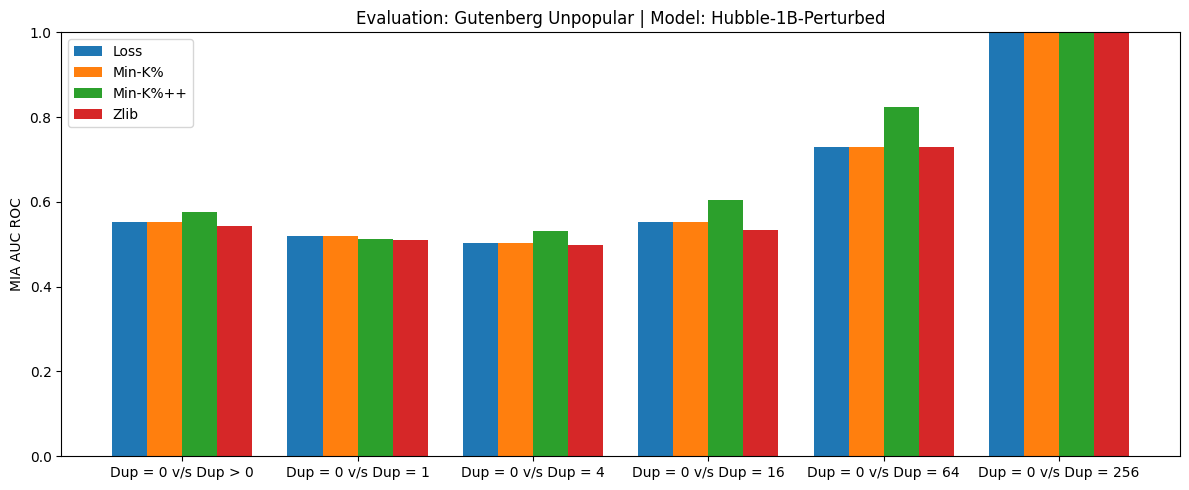

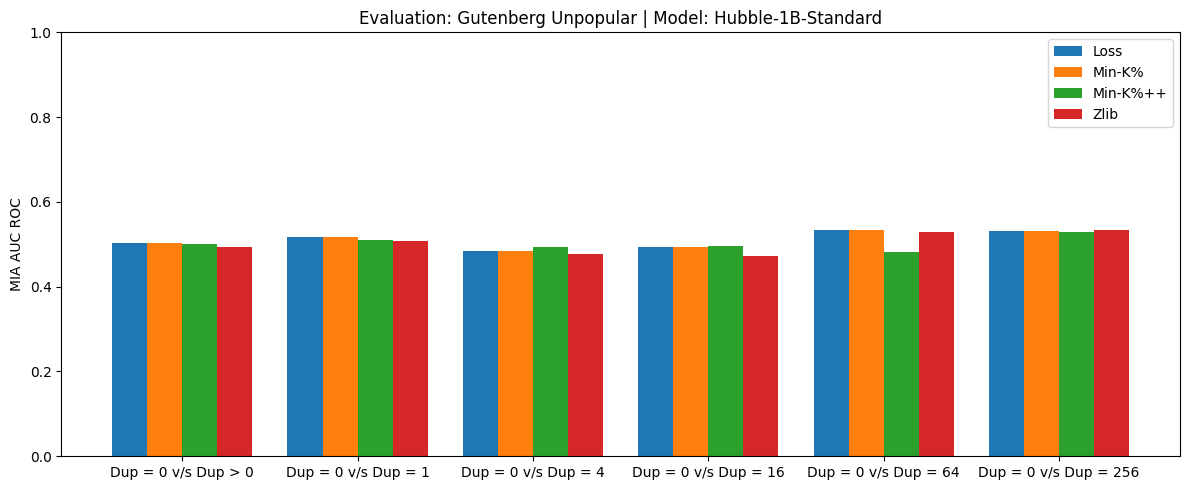

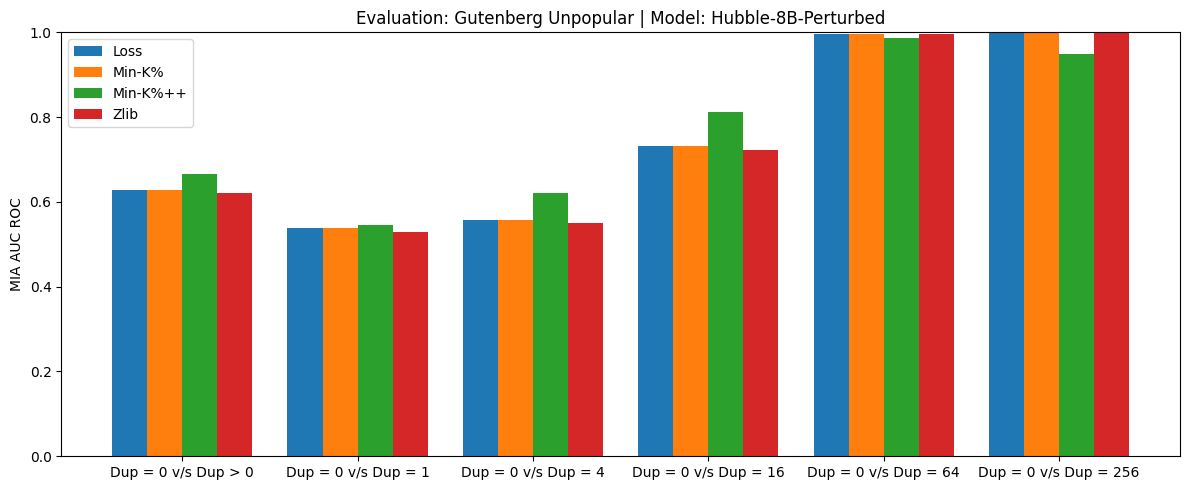

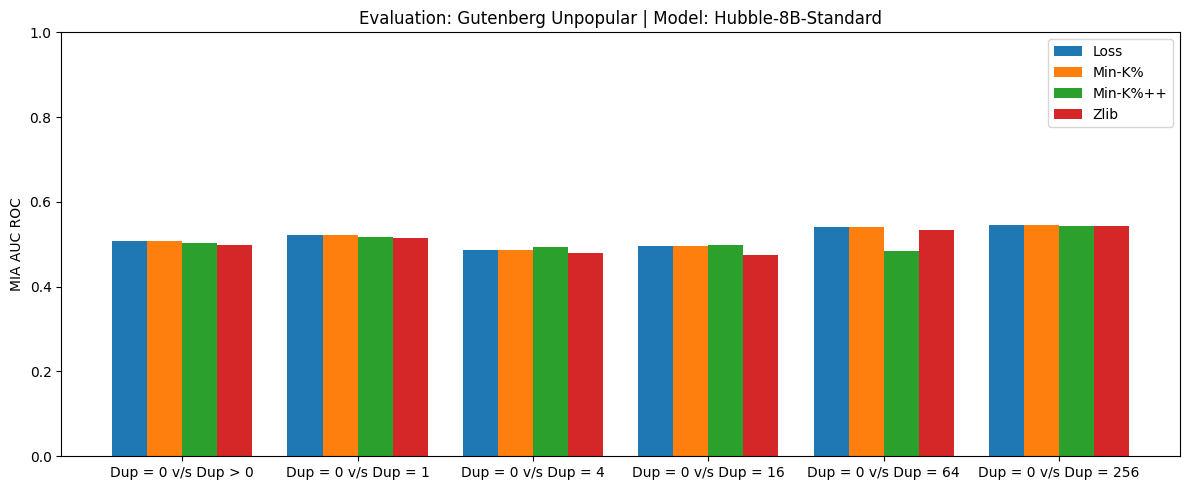

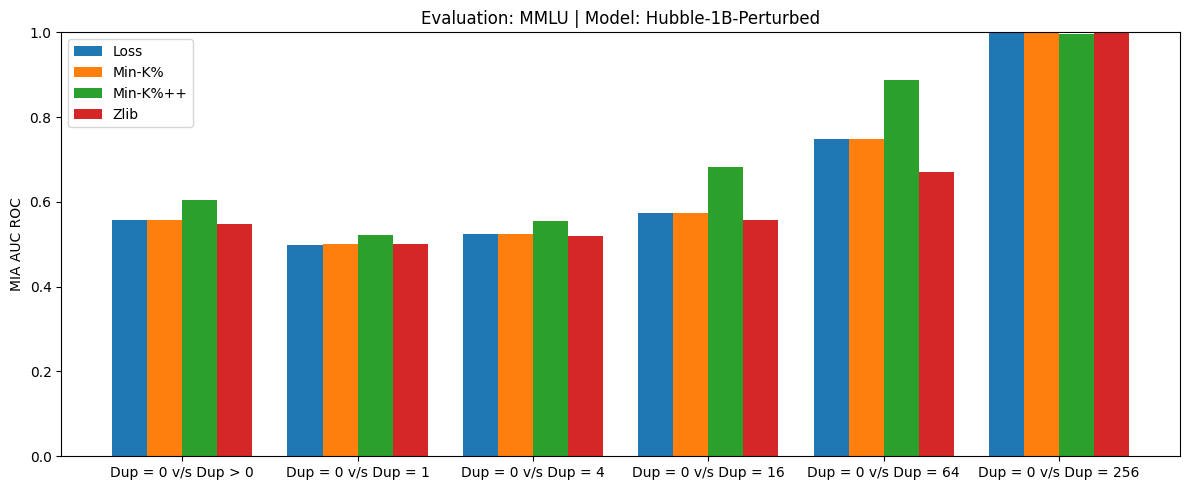

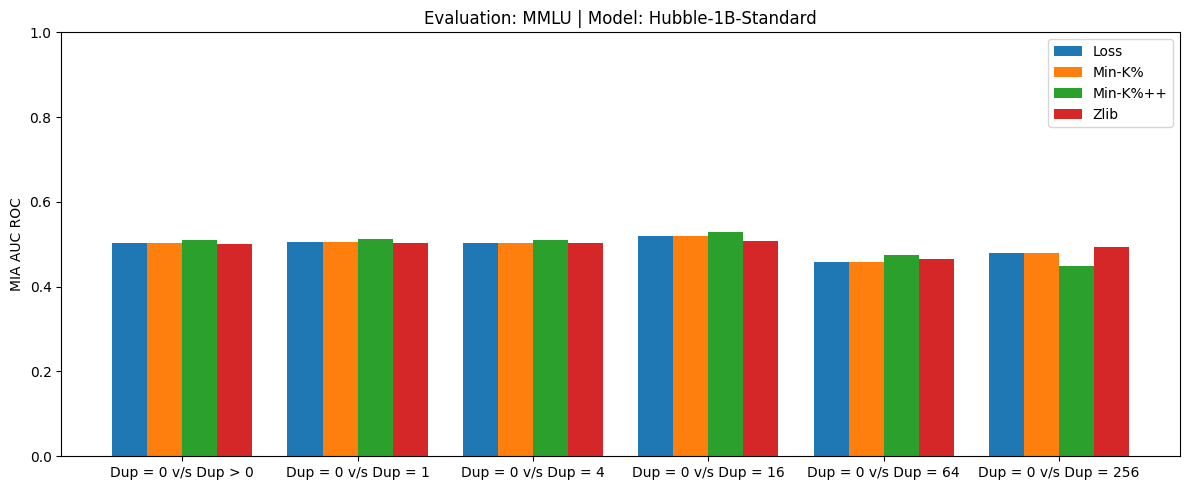

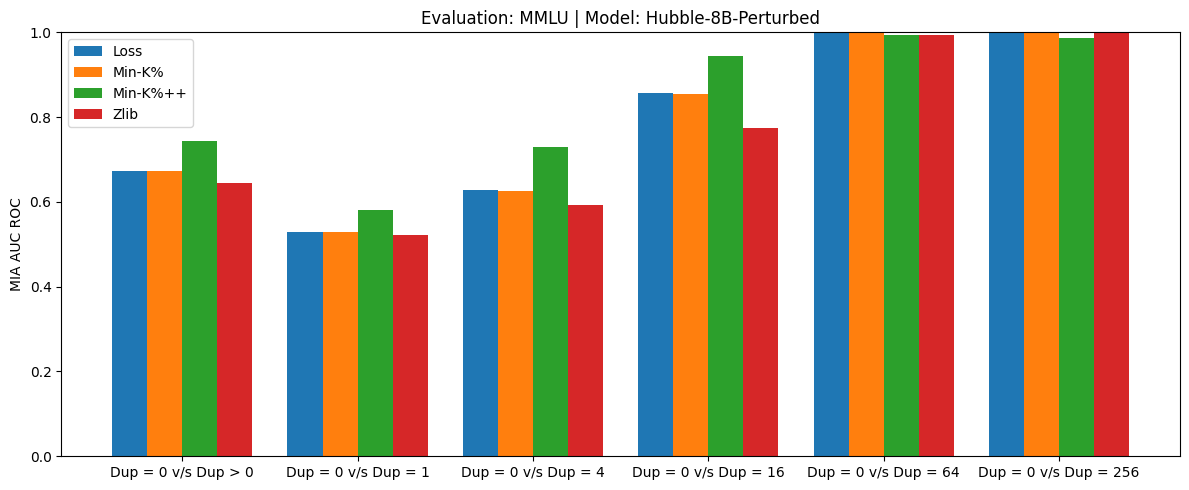

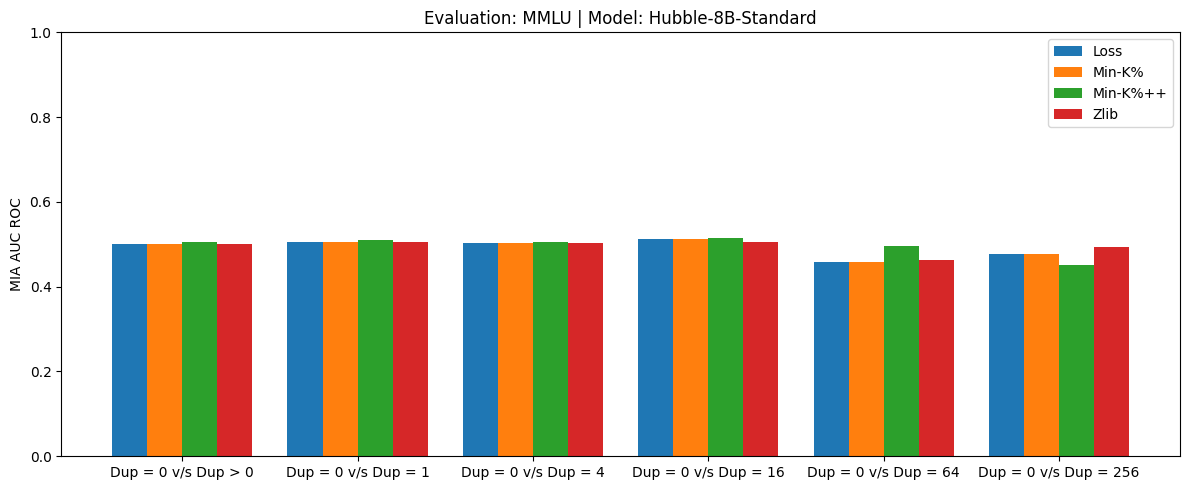

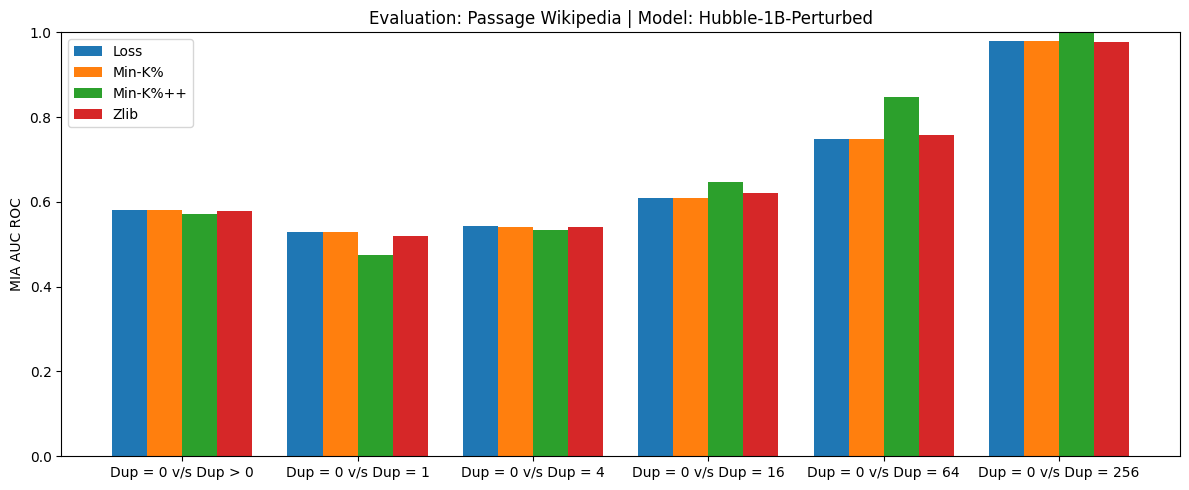

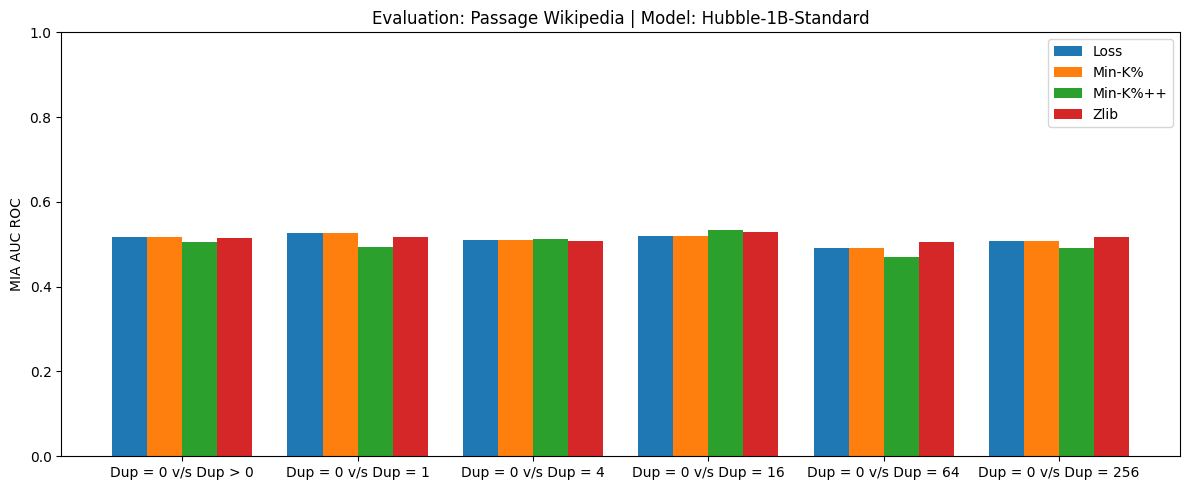

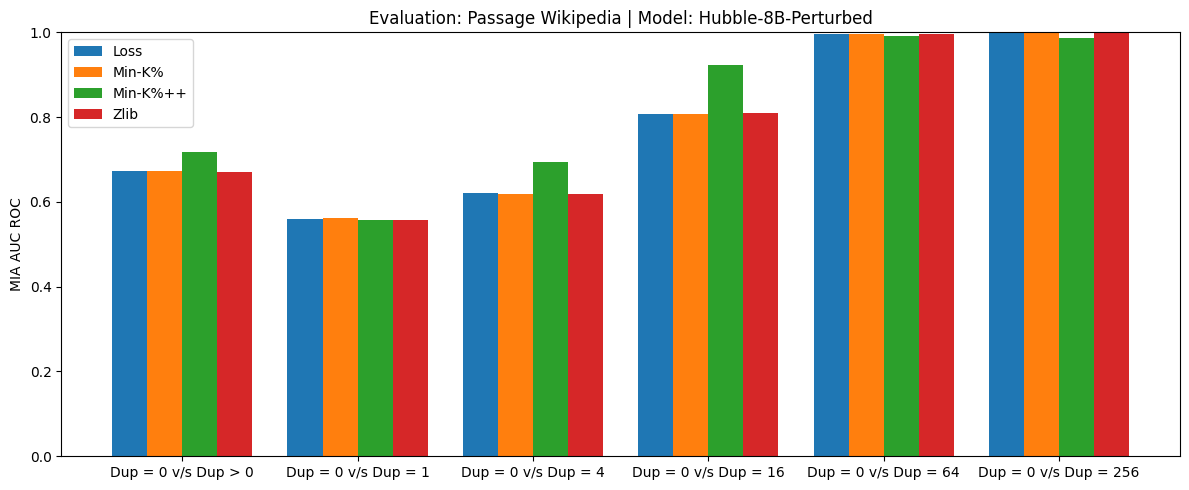

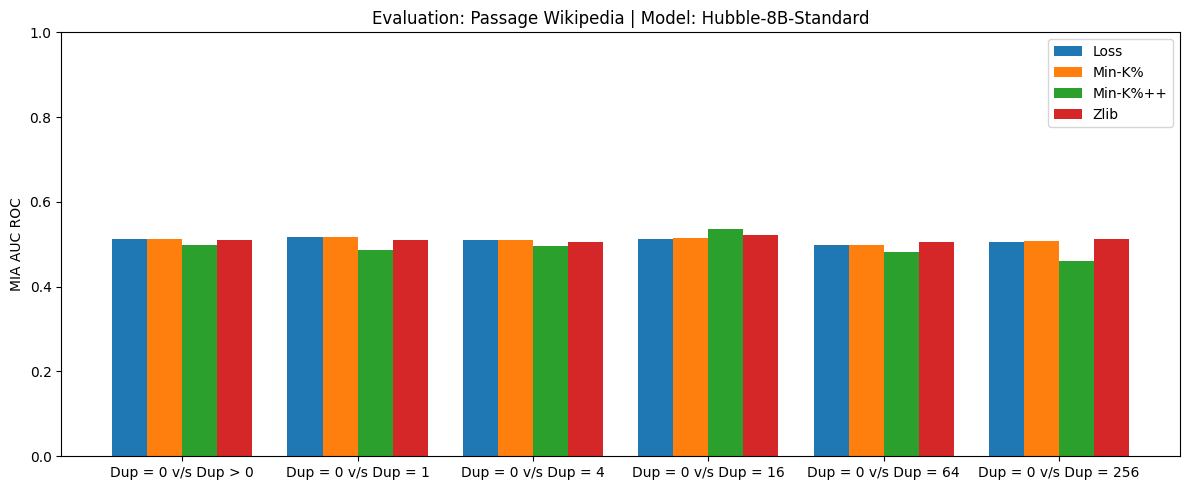

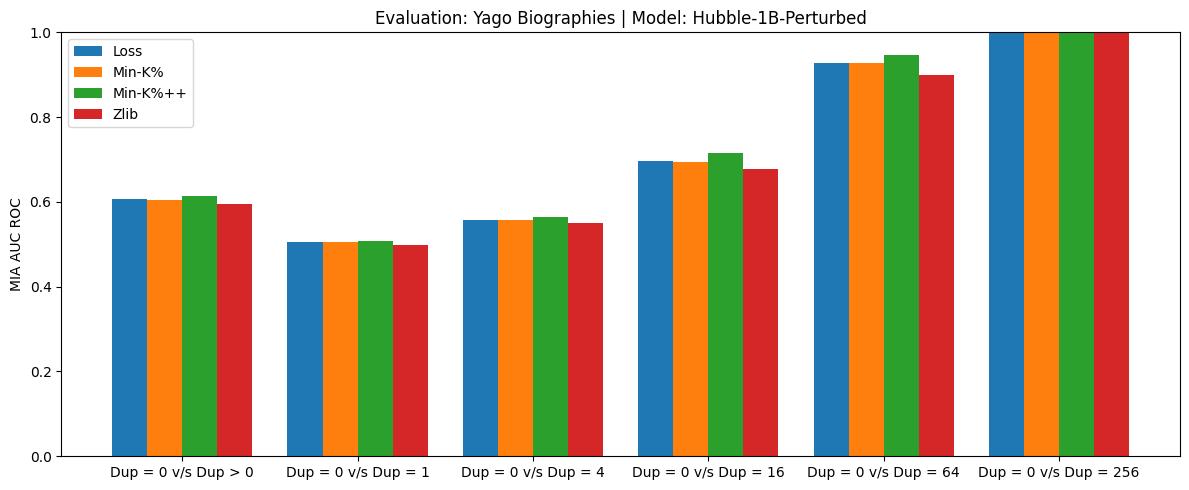

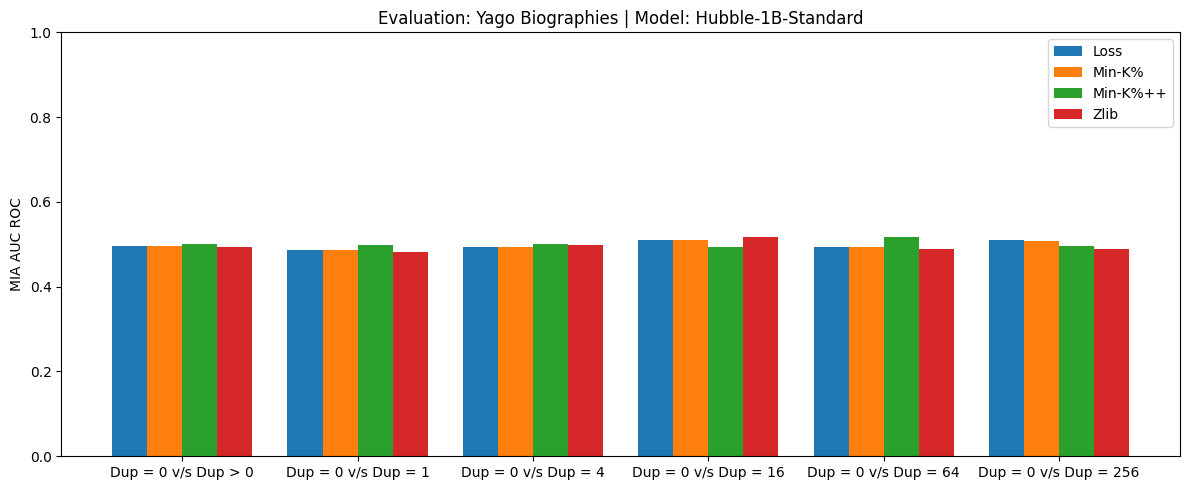

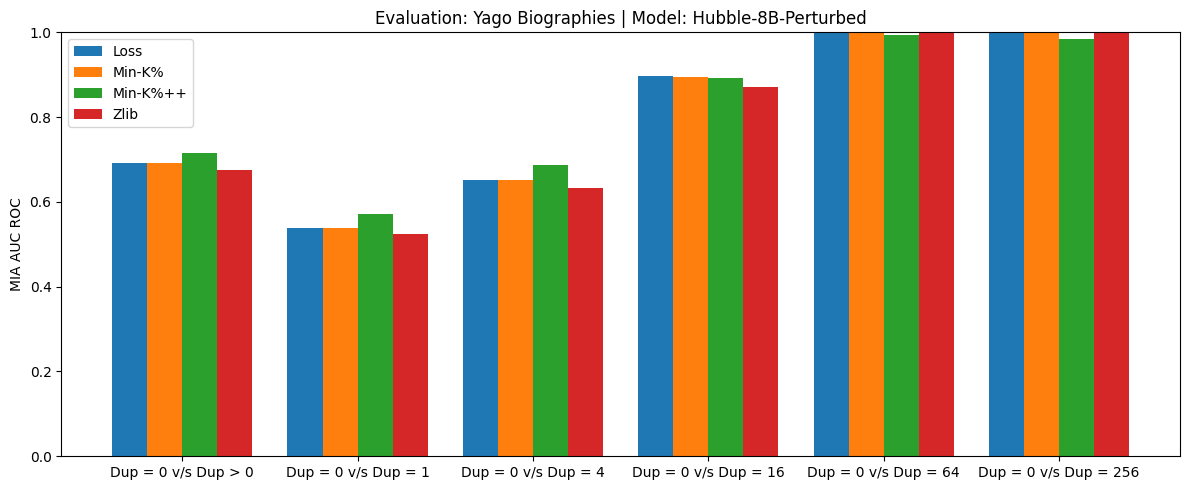

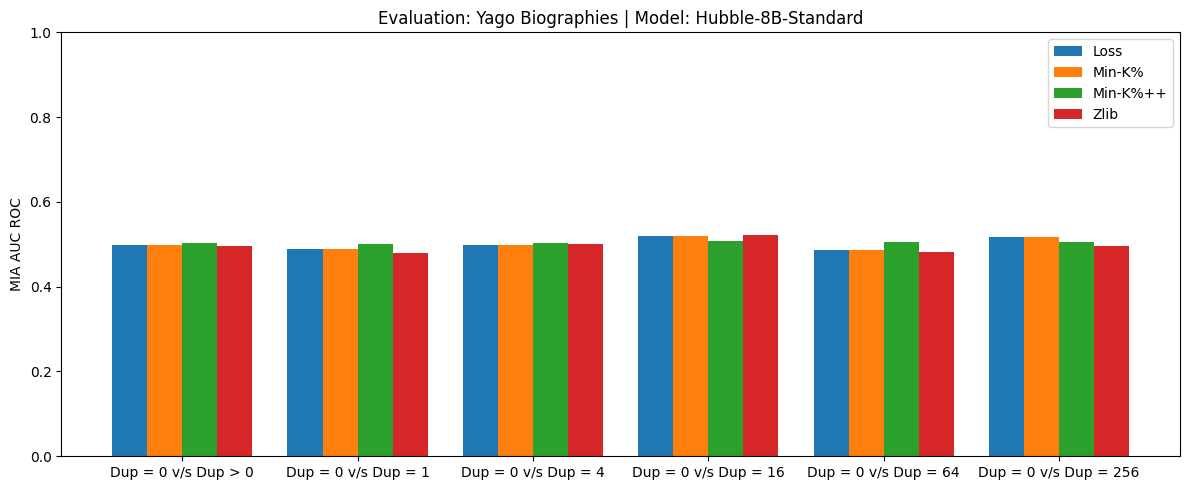

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Melt to long format, keep parameter_value for numeric ordering
df_long = df.melt(
    id_vars=["evaluation", "model", "forget_set_dup", "parameter_value"],  # ✅ keep param
    value_vars=["mia_loss", "mia_min_k", "mia_min_k_plus_plus", "mia_zlib"],
    var_name="metric",
    value_name="value"
)

# Iterate over eval-model combos
for (eval_name, model_name), df_subset in df_long.groupby(["evaluation", "model"]):
    plt.figure(figsize=(12, 5))
    ax = plt.gca()

    # Sort numerically
    df_subset = df_subset.sort_values(by="parameter_value")

    # Pivot so each metric is a column
    df_pivot = df_subset.pivot_table(
        index=["parameter_value", "forget_set_dup"],  # ✅ include param
        columns="metric",
        values="value"
    ).reset_index()

    # X positions
    bar_width = 0.2
    metrics = ["mia_loss", "mia_min_k", "mia_min_k_plus_plus", "mia_zlib"]
    x = range(len(df_pivot))

    # Plot 4 bars per forget_set_dup
    for i, metric in enumerate(metrics):
        ax.bar(
            [pos + i * bar_width for pos in x],
            df_pivot[metric],
            width=bar_width,
            label=metrics_to_legend_mapping[metric]
        )

    # y limit 0 to 1
    ax.set_ylim(0, 1)

    # X labels
    ax.set_xticks([pos + 1.5 * bar_width for pos in x])
    ax.set_xticklabels(df_pivot["forget_set_dup"].astype(str), rotation=0)

    eval_name = " ".join(eval_name.split("_")).title()

    if eval_name == 'Mmlu':
        eval_name = 'MMLU'
    
    title_model_name = "Hubble"
    if '1b' in model_name:
        title_model_name += "-1B"
    elif '8b' in model_name:
        title_model_name += "-8B"
    else:
        raise ValueError("Unexpected model name")
    
    if 'perturbed' in model_name:
        title_model_name += "-Perturbed"
    elif 'standard' in model_name:
        title_model_name += "-Standard"
    else:
        raise ValueError("Unexpected model name")

    ax.set_title(f"Evaluation: {eval_name} | Model: {title_model_name}")
    ax.set_ylabel("MIA AUC ROC")
    ax.legend()
    plt.tight_layout()

    save_path = os.path.join(plot_folder, f"model_eval_wise/eval_{eval_name}_model_{model_name}.pdf")
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, format='pdf', dpi=500, bbox_inches='tight')
